# UC San Diego: Neural Data Science
## Mapping the Stress Brain: Glucocorticoid Receptor Gene Expression and Behavioral Associations Across Stress-Sensitive Regions.

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [  ] YES - make available
* [  ] NO - keep private

# Names

| Name | PID |
|---|---|
| Khang Quach | A_______ |
| Veeratat K. | A12468077 |
| Brandon Melendez-Rodriguez | A_______ |
| Hyojeong Lee | A18491673 |

# Overview

In this project, we investigated the molecular and behavioral landscapes of the human stress response across three core brain regions: the hippocampus, amygdala, and prefrontal cortex. Using gene expression microarray data from the Allen Human Brain Atlas, we analyzed the expression profiles of key stress-regulation genes, namely NR3C1, NR3C2, and FKBP5. We then integrated these molecular signatures with literature text-mining data from LISC to evaluate co-occurrence frequencies with stress-related behavioral terms in PubMed. Our multi-modal computational pipeline successfully links regional receptor densities to their functional and cognitive associations in published neuroscience literature.

<a id='research_question'></a>
# Research Question

* Do the three core stress-sensitive brain regions, the amygdala, hippocampus, and prefrontal cortex,  show distinct glucocorticoid receptor gene expression patterns, specifically in NR3C1, NR3C2, and FKBP5 regions in the human brain, and do these molecular patterns align with the behavioral and cognitive terms most associated with each region in the published neuroscientific literature?


<a id='background'></a>

## Background & Prior Work

* Stress is something everyone experiences and cannot avoid. It is a natural response our body produces when we face challenging situations. Without us even realizing it, deep inside our brain and body, stress activates the hypothalamic pituitary adrenal (HPA) axis, culminating in the adrenal glands releasing cortisol into the body. Cortisol plays a vital role in how we function daily because it is primarily responsible for regulating our overall stress response and returning the body to a balanced/relaxing state and transition so that we can rest or sleep. For some individuals, the body may produce dysregulated or unbalanced cortisol levels without them realizing it. This can disrupt daily life, emotional regulation, cognitive function, and overall mental health, potentially leading to severe long-term consequences like mental breakdown or worse. So, what exactly does cortisol do? It mainly affects the brain through two important receptors: the glucocorticoid receptor (GR/NR3C1) and the mineralocorticoid receptor (MR/NR3C2). Another gene, FKBP5, is also commonly used as a marker for cortisol sensitivity. Together, these genes are involved in the brain’s main molecular response to stress and will be the focus of our study.
* The three brain regions most related to stress are the amygdala, hippocampus, and prefrontal cortex (PFC). Each of these regions has its own role: the amygdala is involved in detecting and responding to threat and fear, the hippocampus controls memory (including the transition from STM to LTM) and HPA-axis feedback, and the PFC regulates cognition and emotions. Because these regions are heavily regulated by cortisol levels, their pathways linked to the NR3C1, NR3C2, and FKBP5 genes, they are highly vulnerable to prolonged stress. Previous studies have shown that chronic stress and high cortisol levels are associated with structural and functional changes in all three brain regions (Pagliaccio et al., 2014), directly contributing to adverse mental health behaviors such as severe anxiety, memory impairment, and major depression.
* To study this further, we will combine gene expression data from the Allen Human Brain Atlas (Hawrylycz et al., 2012) with behavioral association data from LISC. Similar approaches have been used before, such as in van der Meer et al. (2020), where the Allen Atlas was used to identify molecular signatures related to stress brain networks. In our project, we aim to compare gene expression patterns with behavioral co-occurrence data across these three important brain regions.


References (include links):
- 1) Hawrylycz, M. J., et al. (2012). An anatomically comprehensive atlas of the adult human brain transcriptome. Nature, 489, 391-399. https://doi.org/10.1038/nature11405
- 2) Pagliaccio, D., et al. (2014). Stress-system genes and life stress predict cortisol levels and amygdala and hippocampal volumes in children. Neuropsychopharmacology, 39(5), 1245-1253. https://doi.org/10.1038/npp.2013.336
- 3) van der Meer, D., et al. (2020). Brain scanning the city: Identifying stress-related brain regions using the Allen Human Brain Atlas. Translational Psychiatry, 10, 176.  https://doi.org/10.1038/s41398-020-0854-y
- 4) [Allen Microarray](https://human.brain-map.org/)
- 5) [LISC](https://lisc-tools.github.io/lisc/auto_tutorials/index.html)

# Hypothesis


We hypothesize that the hippocampus will show the highest expression of NR3C1 and NR3C2 among the three regions, and that all three regions will show strong co-occurrence with stress and anxiety terms in the literature, with the amygdala most associated with fear and the PFC most associated with emotion regulation.

# Dataset(s)

- **Dataset Name:** Allen Human Brain Atlas (Microarray Survey)
- **Link to the dataset:** https://human.brain-map.org/
- **Number of observations:** Capped at 15 samples per brain region (Hippocampal formation, Amygdala, Frontal lobe) across adult donor brains to comply with DataHub memory limits.
- **Description:** This dataset provides comprehensive z-scored gene expression values across thousands of anatomically precise tissue samples in the adult human brain, allowing us to profile the baseline density of glucocorticoid and mineralocorticoid receptors.

- **Dataset Name:** LISC (Literature-based Information for Scientists in Computational Neuroscience)
- **Link to the dataset:** https://lisc-tools.github.io/lisc/
- **Number of observations:** Co-occurrence counts from PubMed queries combining 3 brain region terms with 6 behavioral keywords ('cortisol', 'stress', 'depression', 'anxiety', 'fear', 'memory').
- **Description:** LISC automatically mines online PubMed literature in real-time to generate a co-occurrence frequency matrix, quantifying how strongly specific brain structures are associated with cognitive and behavioral concepts in published research.

- **Dataset Combination Strategy:** We extracted the mean gene expression z-scores for each target region from the Allen Atlas and correlated them directly with the normalized behavioral co-occurrence frequencies obtained from LISC using scatter plots and trendlines.

### Problem:
Ran into problem, Datahub version of LISC is too old

In [3]:
# ran into problem, Datahub version of LISC is too old
!pip install --upgrade beautifulsoup4 -q
!pip install --upgrade lisc -q

In [4]:
#%%capture mute output
#!pip install lisc
#print("Lisc installed uccessfully!")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import lisc

from scipy import stats
from lisc import Counts

print("LISC version:", lisc.__version__)

LISC version: 0.4.0


# Data Wrangling

* Explain steps taken to pull the data you need into Python.

## Installing: using API base URL

In [6]:
# Luckily Allen Human Brain Atlas has an API base URL, which makes thing easiler for us save/extracting file


## Installing: CSV file to local machine
### Dataset 1: Allen Human Brain Atlas setup
- Goal: 3 brain regions; 
    - NR3C1 : hippo
    - NR3C2 : amy
    - FKBP5 : PFC

In [7]:
# Load Expression data (z-scored expression values per probe per sample)
expr_NR3C1 = pd.read_csv('NR3C1/Expression.csv', header=None)
expr_NR3C2 = pd.read_csv('NR3C2/Expression.csv', header=None)
expr_FKBP5 = pd.read_csv('FKBP5/Expression.csv', header=None)

# Load Columns data (sample metadata — brain region, donor info)
cols_NR3C1 = pd.read_csv('NR3C1/Columns.csv')
cols_NR3C2 = pd.read_csv('NR3C2/Columns.csv')
cols_FKBP5 = pd.read_csv('FKBP5/Columns.csv')

# Load Probes data (probe metadata)
probes_NR3C1 = pd.read_csv('NR3C1/Probes.csv')
probes_NR3C2 = pd.read_csv('NR3C2/Probes.csv')
probes_FKBP5 = pd.read_csv('FKBP5/Probes.csv')

print("NR3C1 probes:", probes_NR3C1['gene-symbol'].values)
print("NR3C2 probes:", probes_NR3C2['gene-symbol'].values)
print("FKBP5 probes:", probes_FKBP5['gene-symbol'].values)

# Check p
print(cols_NR3C1.columns.tolist())
print(cols_NR3C2.columns.tolist())
print(cols_FKBP5.columns.tolist())

# Check size
print(cols_NR3C1.shape)
print(cols_NR3C2.shape)
print(cols_FKBP5.shape)

# Display how dataset looks like
display(cols_NR3C1.head())
display(cols_NR3C2.head())
display(cols_FKBP5.head())

NR3C1 probes: ['NR3C1' 'NR3C1' 'NR3C1' 'NR3C1' 'NR3C1']
NR3C2 probes: ['NR3C2' 'NR3C2']
FKBP5 probes: ['FKBP5' 'FKBP5' 'FKBP5' 'FKBP5']
['donor_id', 'donor_name', 'donor_age', 'donor_color', 'sample_well', 'sample_polygon', 'sample_mri_0', 'sample_mri_1', 'sample_mri_2', 'structure_id', 'structure_name', 'structure_abbreviation', 'structure_color', 'top_level_structure_id', 'top_level_structure_name', 'top_level_structure_abbreviation', 'top_level_structure_color']
['donor_id', 'donor_name', 'donor_age', 'donor_color', 'sample_well', 'sample_polygon', 'sample_mri_0', 'sample_mri_1', 'sample_mri_2', 'structure_id', 'structure_name', 'structure_abbreviation', 'structure_color', 'top_level_structure_id', 'top_level_structure_name', 'top_level_structure_abbreviation', 'top_level_structure_color']
['donor_id', 'donor_name', 'donor_age', 'donor_color', 'sample_well', 'sample_polygon', 'sample_mri_0', 'sample_mri_1', 'sample_mri_2', 'structure_id', 'structure_name', 'structure_abbreviation', 

,donor_id,donor_name,donor_age,donor_color,sample_well,sample_polygon,sample_mri_0,sample_mri_1,sample_mri_2,structure_id,structure_name,structure_abbreviation,structure_color,top_level_structure_id,top_level_structure_name,top_level_structure_abbreviation,top_level_structure_color
0,9861,H0351.2001,24 years,EC891D,154,27255,74,96,29,4053,anterior orbital gyrus,AOrG,E8BF59,4009,frontal lobe,FL,E8CD59
1,9861,H0351.2001,24 years,EC891D,859,39232,129,78,81,4078,frontal operculum,fro,E8C159,4009,frontal lobe,FL,E8CD59
2,9861,H0351.2001,24 years,EC891D,97,28028,85,96,19,4888,frontal pole,FP,E8C359,4009,frontal lobe,FL,E8CD59
3,9861,H0351.2001,24 years,EC891D,123,27165,94,102,26,4047,gyrus rectus,GRe,E8C459,4009,frontal lobe,FL,E8CD59
4,9861,H0351.2001,24 years,EC891D,539,36756,145,75,66,4041,"inferior frontal gyrus, opercular part",opIFG,E8C659,4009,frontal lobe,FL,E8CD59


,donor_id,donor_name,donor_age,donor_color,sample_well,sample_polygon,sample_mri_0,sample_mri_1,sample_mri_2,structure_id,structure_name,structure_abbreviation,structure_color,top_level_structure_id,top_level_structure_name,top_level_structure_abbreviation,top_level_structure_color
0,9861,H0351.2001,24 years,EC891D,154,27255,74,96,29,4053,anterior orbital gyrus,AOrG,E8BF59,4009,frontal lobe,FL,E8CD59
1,9861,H0351.2001,24 years,EC891D,859,39232,129,78,81,4078,frontal operculum,fro,E8C159,4009,frontal lobe,FL,E8CD59
2,9861,H0351.2001,24 years,EC891D,97,28028,85,96,19,4888,frontal pole,FP,E8C359,4009,frontal lobe,FL,E8CD59
3,9861,H0351.2001,24 years,EC891D,123,27165,94,102,26,4047,gyrus rectus,GRe,E8C459,4009,frontal lobe,FL,E8CD59
4,9861,H0351.2001,24 years,EC891D,539,36756,145,75,66,4041,"inferior frontal gyrus, opercular part",opIFG,E8C659,4009,frontal lobe,FL,E8CD59


,donor_id,donor_name,donor_age,donor_color,sample_well,sample_polygon,sample_mri_0,sample_mri_1,sample_mri_2,structure_id,structure_name,structure_abbreviation,structure_color,top_level_structure_id,top_level_structure_name,top_level_structure_abbreviation,top_level_structure_color
0,9861,H0351.2001,24 years,EC891D,154,27255,74,96,29,4053,anterior orbital gyrus,AOrG,E8BF59,4009,frontal lobe,FL,E8CD59
1,9861,H0351.2001,24 years,EC891D,859,39232,129,78,81,4078,frontal operculum,fro,E8C159,4009,frontal lobe,FL,E8CD59
2,9861,H0351.2001,24 years,EC891D,97,28028,85,96,19,4888,frontal pole,FP,E8C359,4009,frontal lobe,FL,E8CD59
3,9861,H0351.2001,24 years,EC891D,123,27165,94,102,26,4047,gyrus rectus,GRe,E8C459,4009,frontal lobe,FL,E8CD59
4,9861,H0351.2001,24 years,EC891D,539,36756,145,75,66,4041,"inferior frontal gyrus, opercular part",opIFG,E8C659,4009,frontal lobe,FL,E8CD59


#### Since the size of all 3 files are (1014,17) which are way too big for Datahub, we will need to come up with a method to reduce the size down for faster processing.

### Dataset 2: LISC setup
- once install lise, it automatically queries PubMed's online database directly from pythong in real time.
- meaning, no files involved.
- Goal: 3 regions x 6 keywords

In [8]:
# Define our 3 brain regions (search terms)
regions = ['hippocampus', 'amygdala', 'prefrontal cortex']

# Define our ~6 stress-related behavioral keywords
keywords = ['cortisol', 'stress', 'depression','anxiety', 'fear', 'memory']

print("Regions:", regions)
print("Keywords:", keywords)

Regions: ['hippocampus', 'amygdala', 'prefrontal cortex']
Keywords: ['cortisol', 'stress', 'depression', 'anxiety', 'fear', 'memory']


### Dataset 2.2: Run PubMed queries
- Counts() works with 2D search
  - dim = 'A' 1st term
  - dim = 'B' 2nd term

In [9]:
# LISC Counts object
counts = Counts()

counts.add_terms(regions)                # brain regions
counts.add_terms(keywords, dim = 'B')    # keywords for behavioral 
print('we will now run PubMed queries. This might take awhile')
counts.run_collection()
print('Done!')

we will now run PubMed queries. This might take awhile
Done!


---
# Data Cleaning

* Describe your data cleaning steps here.
### Unfortunately
Upon initial inspection of the downloaded Allen Human Microarray data, we found that the hippocampus was not labeled as 'hippocampus' in the dataset. After investigating the available structure names, we discovered that the Allen Brain Atlas uses the term 'hippocampal formation' instead, which encompasses key subregions including CA1, CA2, CA3, CA4, dentate gyrus, and subiculum. We updated our filter accordingly to correctly capture this region.

### Clearning: Allen Brain Atlas

In [10]:
# lets run another test to see what are there!
# Check ALL structure names available in the data
print("TOP LEVEL structures:")
print(cols_NR3C1['top_level_structure_name'].unique())

print("\nALL structure names (subregions):")
print(cols_NR3C1['structure_name'].unique())

TOP LEVEL structures:
['frontal lobe' 'insula' 'cingulate gyrus' 'hippocampal formation'
 'parahippocampal gyrus' 'brain' 'occipital lobe' 'parietal lobe'
 'temporal lobe' 'amygdala' 'basal forebrain' 'globus pallidus' 'striatum'
 'claustrum' 'epithalamus' 'hypothalamus' 'subthalamus' 'dorsal thalamus'
 'ventral thalamus' 'mesencephalon' 'cerebellar cortex'
 'cerebellar nuclei' 'basal part of pons' 'pontine tegmentum'
 'myelencephalon' 'white matter' 'sulci & spaces']

ALL structure names (subregions):
['anterior orbital gyrus' 'frontal operculum' 'frontal pole'
 'gyrus rectus' 'inferior frontal gyrus, opercular part'
 'inferior frontal gyrus, orbital part'
 'inferior frontal gyrus, triangular part' 'inferior rostral gyrus'
 'lateral orbital gyrus' 'medial orbital gyrus' 'middle frontal gyrus'
 'paracentral lobule, anterior part' 'paraterminal gyrus'
 'parolfactory gyri' 'posterior orbital gyrus' 'precentral gyrus'
 'superior frontal gyrus' 'superior rostral gyrus' 'long insular gyri'


In [11]:
# Define our 3 target brain regions
target_regions = ['hippocampal formation', 'amygdala', 'frontal lobe']

def build_and_filter(expr, cols, gene_name):
    mean_expr = expr.iloc[:, 1:].mean(axis=0).values                          # Step 1: Average expression across all probes for this gene
    
    # Step 2: Keep only the columns we need
    df = cols[['donor_id', 'donor_name', 'donor_age',
               'top_level_structure_name', 'structure_name']].copy()
    df['expression_zscore'] = mean_expr
    df['gene'] = gene_name
    df = df[df['top_level_structure_name'].str.lower().isin(target_regions)]  # Step 3: Filter to our 3 target regions only
    df = df.dropna(subset=['expression_zscore'])                              # Step 4: Drop any missing expression values
    df = (df.groupby('top_level_structure_name', group_keys=False)            # Step 5: Cap to 15 samples per region (DataHub memory limit)
            .apply(lambda x: x.head(15))
            .reset_index(drop=True))
    return df

df_NR3C1 = build_and_filter(expr_NR3C1, cols_NR3C1, 'NR3C1')
df_NR3C2 = build_and_filter(expr_NR3C2, cols_NR3C2, 'NR3C2')
df_FKBP5 = build_and_filter(expr_FKBP5, cols_FKBP5, 'FKBP5')

# Combine everything into 1 dataset
df_comb = pd.concat([df_NR3C1, df_NR3C2, df_FKBP5], ignore_index=True)
print(df_comb.shape)
display(df_comb.head())
print(df_comb.groupby(['gene', 'top_level_structure_name']).size())

(135, 7)


/var/folders/rb/0439ckb531ld0tqp6kxc3cjm0000gn/T/ipykernel_76460/2139130358.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(15))
/var/folders/rb/0439ckb531ld0tqp6kxc3cjm0000gn/T/ipykernel_76460/2139130358.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(15))
/var/folders/rb/0439ckb531ld0tqp6kxc3cjm0000gn/T/ipykernel_76460/2139130358.py:15: Deprecation

,donor_id,donor_name,donor_age,top_level_structure_name,structure_name,expression_zscore,gene
0,9861,H0351.2001,24 years,amygdala,amygdalohippocampal transition zone,-0.92070,NR3C1
1,9861,H0351.2001,24 years,amygdala,basolateral nucleus,-0.24638,NR3C1
2,9861,H0351.2001,24 years,amygdala,basomedial nucleus,0.92838,NR3C1
3,9861,H0351.2001,24 years,amygdala,central nucleus,-1.84160,NR3C1
4,9861,H0351.2001,24 years,amygdala,cortico-medial group,-0.39728,NR3C1


gene   top_level_structure_name
FKBP5  amygdala                    15
       frontal lobe                15
       hippocampal formation       15
NR3C1  amygdala                    15
       frontal lobe                15
       hippocampal formation       15
NR3C2  amygdala                    15
       frontal lobe                15
       hippocampal formation       15
dtype: int64


### Clearning: LISC

In [12]:
# Convert results to a clean DataFrame
df_lisc = pd.DataFrame(
    counts.counts,
    index=regions,
    columns=keywords
)

print("-------------Co-occurrence matrix:-------------")
display(df_lisc)

# Normalize by row
df_lice_norm = df_lisc.div(df_lisc.sum(axis=1),axis=0)
print("-------------Normalized matrix:-------------")
display(df_lice_norm)

-------------Co-occurrence matrix:-------------


,cortisol,stress,depression,anxiety,fear,memory
hippocampus,926,20544,12869,8238,4647,40524
amygdala,513,7723,4604,7159,6168,6978
prefrontal cortex,474,8104,8293,5639,2640,13201


-------------Normalized matrix:-------------


,cortisol,stress,depression,anxiety,fear,memory
hippocampus,0.010553,0.234125,0.146659,0.093882,0.052958,0.461822
amygdala,0.015477,0.233006,0.138905,0.215990,0.186091,0.210529
prefrontal cortex,0.012360,0.211311,0.216239,0.147037,0.068838,0.344215


---
# Data Visualization

* This is a good place for some relevant visualizations related to any exploratory data anlayses (EDA) you did after the basic cleaning.

## Data Analysis & Results

In this section, we carry out our full analysis pipeline across both datasets. 
The following steps are performed in order:

- [x] **1. Bar Chart** — Mean z-scored expression of NR3C1, NR3C2, and FKBP5 across the amygdala, hippocampus, and prefrontal cortex
    - [ ] **help me pick what colors we should use to represent brain regions
- [ ] **2. Heatmap** — Z-score expression per gene per brain region for a quick visual comparison
- [ ] **3. LISC Heatmap** — Co-occurrence matrix of brain regions × behavioral keywords mined from PubMed literature
- [ ] **4. Scatter Plot** — Correlation between NR3C1 expression levels per region and stress/cortisol literature frequency
- [ ] **5. ANOVA** — Statistical test to determine whether gene expression differs significantly across the three brain regions

## 1. Bar Chart
- Mean z-scored of 3x Allen Brain Atlas datasets

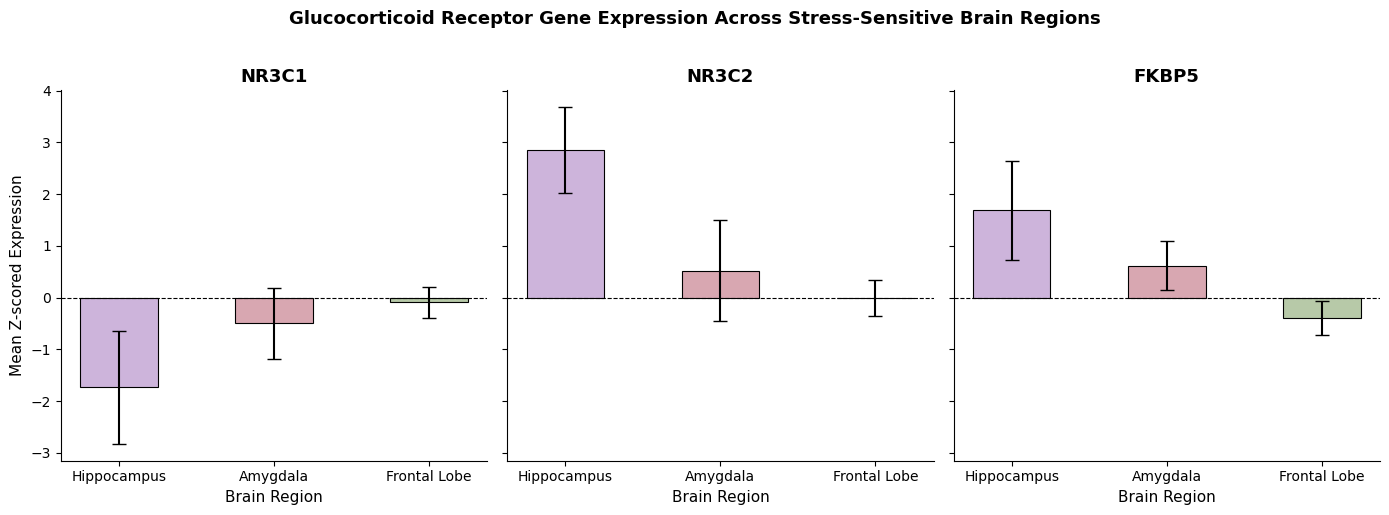

In [13]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

genes = ['NR3C1', 'NR3C2', 'FKBP5']
regions_labels = ['hippocampal formation', 'amygdala', 'frontal lobe']
colors = ['#CDB4DB',  # Hippocampus — cool blue (calm, memory, learning)
          '#D8A7B1',  # Amygdala — warm pink/red (threat, fear, emotion)
          '#B7C9A8']  # Frontal Lobe — soft green (control, regulation, rational)

for ax, gene in zip(axes, genes):
    # Filter data for this gene
    df_gene = df_comb[df_comb['gene'] == gene]
    
    # Compute mean and std per region
    means = df_gene.groupby('top_level_structure_name')['expression_zscore'].mean()
    stds  = df_gene.groupby('top_level_structure_name')['expression_zscore'].std()
    
    # Reorder to match our region order
    means = means.reindex(regions_labels)
    stds  = stds.reindex(regions_labels)
    
    # Shorter labels for display
    short_labels = ['Hippocampus', 'Amygdala', 'Frontal Lobe']
    
    # Plot bars
    bars = ax.bar(short_labels, means.values, 
                  yerr=stds.values,
                  color=colors, 
                  edgecolor='black',
                  linewidth=0.8,
                  capsize=5,
                  width=0.5)
    
    # Labels and formatting
    ax.set_title(gene, fontsize=13, fontweight='bold')
    ax.set_xlabel('Brain Region', fontsize=11)
    ax.set_xticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels, rotation=0, ha='center')    # change rotation=15 and ha='right' if needed for better look
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared y label
axes[0].set_ylabel('Mean Z-scored Expression', fontsize=11)

# Main title
fig.suptitle('Glucocorticoid Receptor Gene Expression Across Stress-Sensitive Brain Regions',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

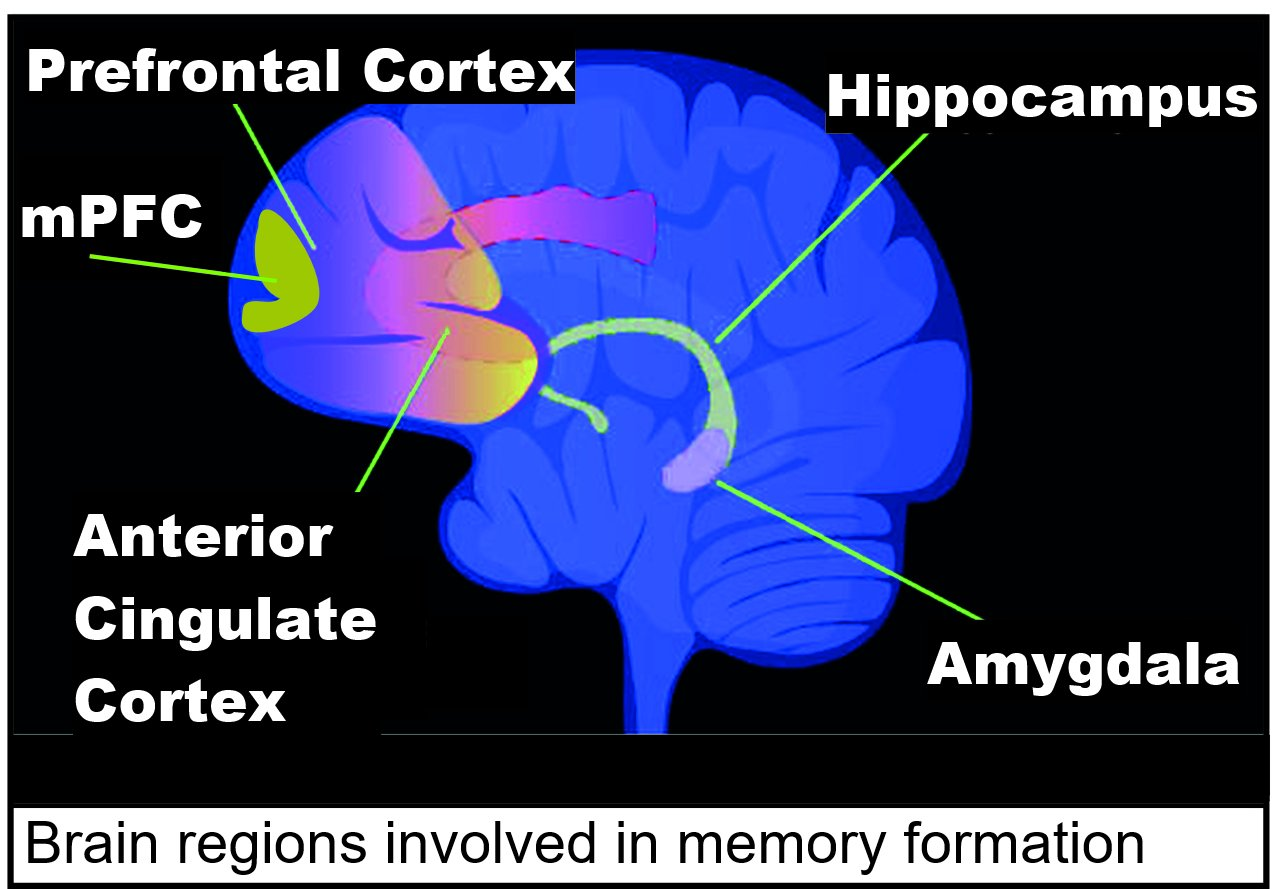

In [14]:
from IPython.display import Image, display
display(Image('Brain_regions_in_memory_formation_updated.jpg', width=500))
# pic from https://commons.wikimedia.org/wiki/File:Brain_regions_in_memory_formation_updated.jpg

## 2. Heatmap

In [15]:
# Computing mean z-score 1 gene per region
display(df_comb.columns.tolist())
heatmap_data = (df_comb.groupby(['gene','top_level_structure_name'])['expression_zscore'].mean().unstack())
# re-ordering columns
heatmap_data = heatmap_data[['hippocampal formation','amygdala','frontal lobe']]
display(heatmap_data.head())
heatmap_data = heatmap_data.reindex(['NR3C1','NR3C2','FKBP5'])
heatmap_data.columns = ['Hippocampus','Amygdala','Frontal Lobe']
heatmap_data.head()

['donor_id',
 'donor_name',
 'donor_age',
 'top_level_structure_name',
 'structure_name',
 'expression_zscore',
 'gene']

top_level_structure_name,hippocampal formation,amygdala,frontal lobe
gene,,,
FKBP5,1.683950,0.616900,-0.388482
NR3C1,-1.733085,-0.494120,-0.091911
NR3C2,2.847953,0.520407,-0.002587


,Hippocampus,Amygdala,Frontal Lobe
gene,,,
NR3C1,-1.733085,-0.494120,-0.091911
NR3C2,2.847953,0.520407,-0.002587
FKBP5,1.683950,0.616900,-0.388482


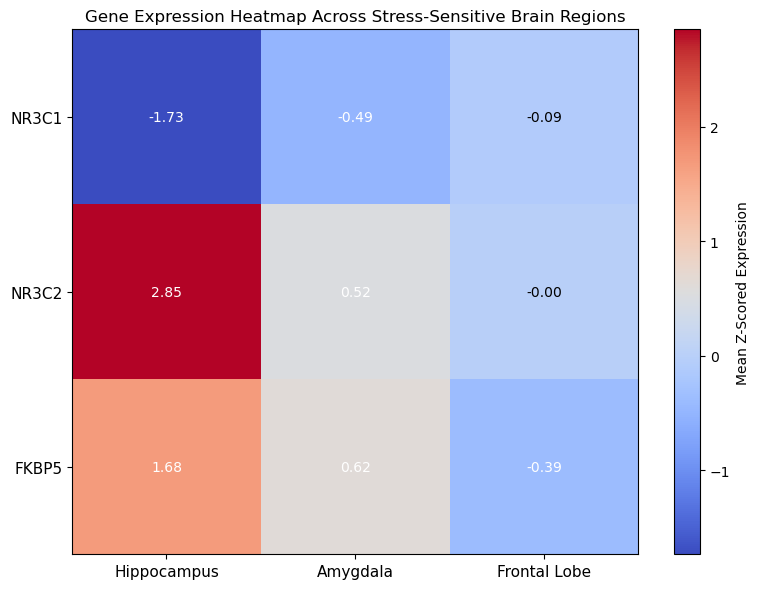

In [16]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
heatmap_image = ax.imshow(heatmap_data.values, cmap='coolwarm', aspect='auto')
colorbar = plt.colorbar(heatmap_image, ax=ax)
colorbar.set_label('Mean Z-Scored Expression')

# Set ticks and labels
ax.set_title('Gene Expression Heatmap Across Stress-Sensitive Brain Regions')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=11)

# Add value annotations inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.2f}', 
                ha='center', 
                va='center',
                color='white' if abs(val) > 0.3 else 'black')

plt.tight_layout()
plt.show()

### Color Choice & Interpretation

The heatmap uses a **Red-Blue diverging colormap (`coolwarm`)** where:
- 🔴 **Red/Warm** = higher z-scored expression (above average)
- 🔵 **Blue/Cool** = lower z-scored expression (below average)
- ⬜ **White-Gray/Neutral** = expression close to the mean (z-score ≈ 0)

This colormap was chosen because our data is **Z-Scored** (centered around 0), 
making a diverging color scale the most intuitive choice — it clearly shows 
which regions are above or below average expression for each gene. The `coolwarm` 
palette was selected for its softer, more visually comfortable gradient compared 
to harsher red-blue colormaps.

**Key observations:**
- **NR3C2** shows the highest expression in the hippocampus (2.85), 
consistent with the hippocampus being the primary target of cortisol via mineralocorticoid receptors
- **NR3C1** shows the lowest expression in the hippocampus (-1.73), 
suggesting glucocorticoid receptors are less dominant there at baseline
- **Frontal Lobe** shows near-zero expression across all genes, 
indicating lower overall stress receptor activity compared to limbic regions

## PCA Plot — Gene Expression Across Brain Regions

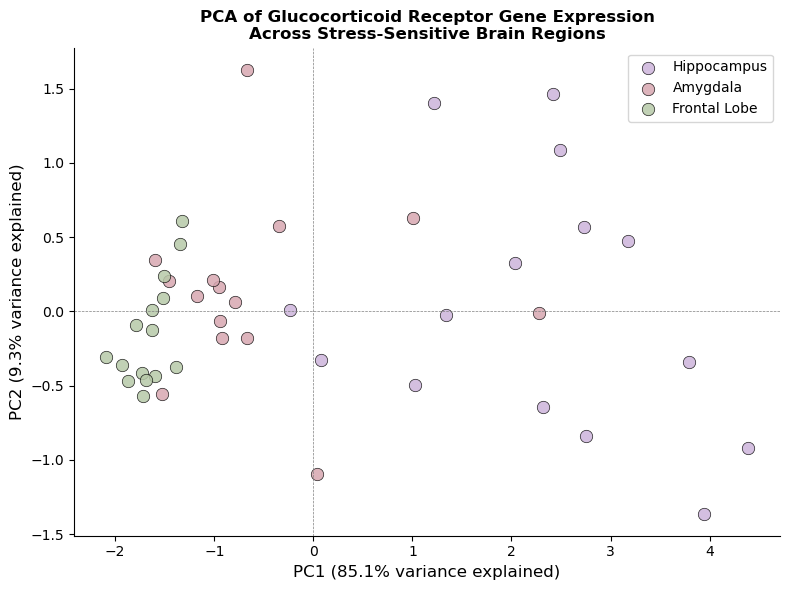

Variance - PC1: 85.1%, PC2: 9.3%
Total variance: 94.4%


In [17]:
from sklearn.decomposition import PCA

# Pivot data so each row = one sample, columns = genes
df_pivot = df_comb.pivot_table(index=['donor_id', 'structure_name', 
                                       'top_level_structure_name'],
                                columns='gene',
                                values='expression_zscore').reset_index()

# Drop any rows with missing values
df_pivot = df_pivot.dropna()

# Extract gene expression matrix (3 genes = 3 features)
X = df_pivot[['NR3C1', 'NR3C2', 'FKBP5']].values

# Apply PCA — reduce 3 genes to 2 components
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

# Add PCA results back to dataframe
df_pivot['PC1'] = X_pca[:, 0]
df_pivot['PC2'] = X_pca[:, 1]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Color per region # same color as barchart
region_colors = {
    'hippocampal formation': '#CDB4DB',  # Hippocampus — cool blue (calm, memory, learning)
    'amygdala':              '#D8A7B1',  # Amygdala — warm pink/red (threat, fear, emotion)
    'frontal lobe':          '#B7C9A8'   # Frontal Lobe — soft green (control, regulation, rational)
}
region_labels = {
    'hippocampal formation': 'Hippocampus',
    'amygdala':              'Amygdala',
    'frontal lobe':          'Frontal Lobe'
}

for region, color in region_colors.items():
    mask = df_pivot['top_level_structure_name'] == region
    ax.scatter(df_pivot.loc[mask, 'PC1'],
               df_pivot.loc[mask, 'PC2'],
               c=color, 
               label=region_labels[region],
               s=80, 
               edgecolors='black', linewidth=0.5, alpha=0.85)

# Add explained variance to axis labels
var_explained = pca.explained_variance_ratio_ * 100
ax.set_title('PCA of Glucocorticoid Receptor Gene Expression\nAcross Stress-Sensitive Brain Regions', fontweight='bold')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)', fontsize=12)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Variance - PC1: {var_explained[0]:.1f}%, PC2: {var_explained[1]:.1f}%")
print("Total variance:", f"{sum(var_explained):.1f}%")

### PCA Interpretation

We applied **Principal Component Analysis (PCA)** to reduce our 3-gene expression 
matrix (NR3C1, NR3C2, FKBP5) into 2 principal components for visualization.

- **PC1 (85.1%)** captures the majority of variance, suggesting one dominant 
pattern of gene expression differences across regions
- **PC2 (9.3%)** captures additional but smaller variation
- **Total variance explained: 94.4%** — meaning almost all information from 
the original 3 genes is preserved in this 2D plot

**Key finding:** The hippocampus (purple) is clearly separated from the amygdala 
and frontal lobe along PC1, suggesting it has a distinctly different glucocorticoid 
receptor gene expression profile — consistent with its known role as the primary 
cortisol target in the stress response.

## 3. LISC Heatmap

### LISC Heatmap — Co-occurrence Matrix

In [18]:
# Build matric from LISC results
df_LISC = pd.DataFrame(counts.counts, index=regions, columns=keywords)
# Normalize by row per region
df_LISC_normalize = df_LISC.div(df_LISC.sum(axis=1), axis=0)
print("LISC Normalize:",df_LISC_normalize.round(3))

LISC Normalize:                    cortisol  stress  depression  anxiety   fear  memory
hippocampus           0.011   0.234       0.147    0.094  0.053   0.462
amygdala              0.015   0.233       0.139    0.216  0.186   0.211
prefrontal cortex     0.012   0.211       0.216    0.147  0.069   0.344


### LISC Heatmap Plot

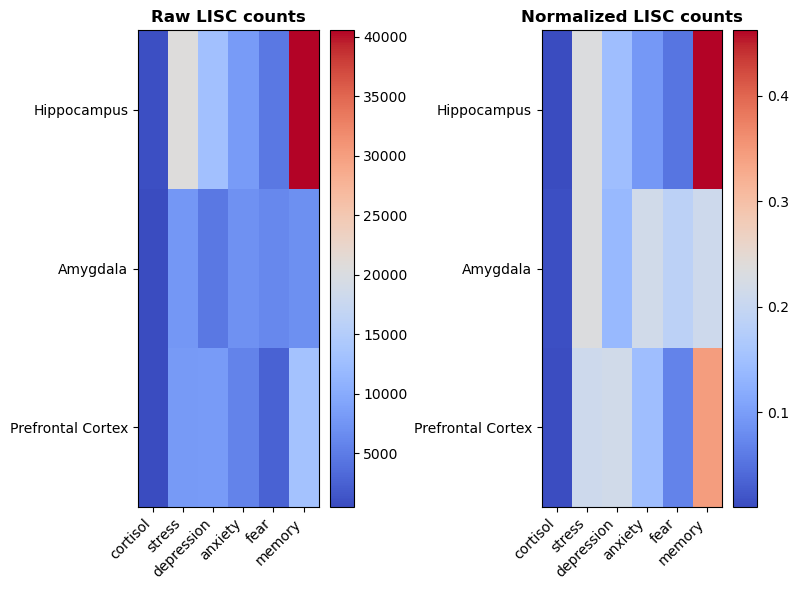

In [19]:
fig, ax = plt.subplots(1,2,figsize=(8, 6)) # 1 = 1 row of plots, 2 = 2 columns of plots

# plot 1: lisc raw counts
image1 = ax[0].imshow(df_LISC.values, cmap='coolwarm', aspect='auto')
plt.colorbar(image1, ax=ax[0])
ax[0].set_title('Raw LISC counts', fontweight='bold')
ax[0].set_xticks(range(len(keywords)))
ax[0].set_xticklabels(keywords, rotation=45, ha='right')
ax[0].set_yticks(range(len(regions)))
ax[0].set_yticklabels(['Hippocampus','Amygdala','Prefrontal Cortex'])

# plot 2: lisc normalize counts
image2 = ax[1].imshow(df_LISC_normalize.values, cmap='coolwarm', aspect='auto')
plt.colorbar(image2, ax=ax[1])
ax[1].set_title('Normalized LISC counts', fontweight='bold')
ax[1].set_xticks(range(len(keywords)))
ax[1].set_xticklabels(keywords, rotation=45, ha='right')
ax[1].set_yticks(range(len(regions)))
ax[1].set_yticklabels(['Hippocampus','Amygdala','Prefrontal Cortex'])

plt.tight_layout()
plt.show()

### LISC Literature Co-occurrence Analysis
To support our gene expression analysis from the Allen Brain Atlas, we also used LISC (Literature-based Information for Scientists in Computational Neuroscience) to examine how often our selected brain regions appear together with stress-related behaviors in the scientific literature.

How does it work?
LISC searches PubMed and counts the number of published studies that mention both a brain region and a behavioral keyword in the same paper. This allows us to see which brain regions are most commonly associated with different stress-related behaviors based on previous research.

Two heatmaps are shown:
- Left (Raw Counts): Shows the actual number of papers that mention both the brain region and the behavioral keyword. Regions such as the hippocampus may naturally have higher counts because they are studied more often.
- Right (Normalized Counts): Shows the proportion of papers for each brain region after adjusting for the total number of publications. This makes it easier to compare regions fairly without being biased by publication volume.

Behavioral keywords used:
- Cortisol
- Stress
- Depression
- Anxiety
- Fear
- Memory

Brain regions examined:
- Hippocampus
- Amygdala
- Prefrontal Cortex (PFC)

### LISC Interpretation
Based on the literature co-occurrence analysis from PubMed, several interesting patterns were observed.

- Memory was the most commonly co-mentioned keyword across all three brain regions, especially in the hippocampus. This is consistent with what we already know about the hippocampus playing a major role in memory formation and consolidation during stress.
- The hippocampus had the highest raw counts overall. This likely reflects the large amount of research that has been published on the hippocampus in relation to stress, learning, and cognition.
- Cortisol showed lower raw counts compared to the other keywords. However, after normalization, cortisol became more noticeable across the brain regions, suggesting that cortisol-related studies are more specialized and focused rather than broadly represented in the literature.
- The amygdala and prefrontal cortex (PFC) showed a more balanced distribution across the different behavioral keywords in the normalized heatmap. This suggests that research on these regions covers a wider range of stress-related emotional and cognitive functions.
- Fear and anxiety showed moderate associations with the amygdala, which is expected given its well-known role in threat detection, emotional processing, and fear responses.

Overall, the literature findings were largely consistent with established neuroscience. The hippocampus appeared most strongly linked to memory and stress research, while the amygdala and prefrontal cortex showed broader associations with emotional regulation, anxiety, fear, and other stress-related behaviors. These findings provide additional support for our decision to focus on these three brain regions in our study of stress and cortisol-related gene expression.

## 4. Scatter Plot

✅ Verification Complete: Required dataframes are successfully loaded. Generating plot...



,Region,NR3C1_Mean_Expression,Stress_Literature_Frequency
0,Hippocampus,-1.733085,0.234125
1,Amygdala,-0.494120,0.233006
2,Prefrontal cortex,-0.091911,0.211311


TypeError: regplot() got an unexpected keyword argument 'linestyle'

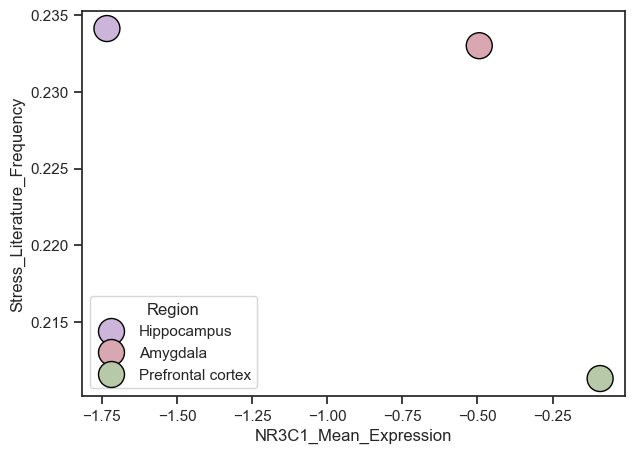

In [20]:
# Cell 18: Correlation Scatter Plot (Gene Expression vs. Literature Frequency)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Verification of variable existence to prevent NameError
if 'df_comb' in locals() and 'df_LISC_normalize' in locals():
    print("✅ Verification Complete: Required dataframes are successfully loaded. Generating plot...\n")
    
    # 1. Create a summary list to map gene expression data with LISC literature metrics
    scatter_data = []
    
    # Mapping index names used in LISC vs Top-level structure names from Allen Atlas
    lisc_names = ['hippocampus', 'amygdala', 'prefrontal cortex']
    allen_names = ['hippocampal formation', 'amygdala', 'frontal lobe']
    
    for l_name, a_name in zip(lisc_names, allen_names):
        # Calculate mean expression value for NR3C1 in each region
        mean_expression = df_comb[(df_comb['gene'] == 'NR3C1') & 
                                  (df_comb['top_level_structure_name'] == a_name)]['expression_zscore'].mean()
        
        # Extract the normalized co-occurrence frequency of 'stress' from LISC matrix
        stress_frequency = df_LISC_normalize.loc[l_name, 'stress']
        
        scatter_data.append({
            'Region': l_name.capitalize(), # Capitalize first letter for professional display
            'NR3C1_Mean_Expression': mean_expression,
            'Stress_Literature_Frequency': stress_frequency
        })
    
    # 2. Construct DataFrame for plotting
    df_scatter_plot = pd.DataFrame(scatter_data)
    display(df_scatter_plot) # Output data preview inside the notebook
    
    # 3. Visualize using Seaborn Scatter Plot
    plt.figure(figsize=(7, 5))
    sns.set_theme(style="ticks")
    
    # Color palette matching the team's presentation theme
    color_palette = {
        'Hippocampus': '#CDB4DB',      # Cool purple/blue
        'Amygdala': '#D8A7B1',         # Warm pink
        'Prefrontal cortex': '#B7C9A8' # Soft green
    }
    
    # Draw large bubble markers for legibility
    sns.scatterplot(
        data=df_scatter_plot, 
        x='NR3C1_Mean_Expression', 
        y='Stress_Literature_Frequency', 
        hue='Region', 
        s=350, # Increased marker size for bubble plot presentation format
        palette=color_palette,
        edgecolor='black',
        linewidth=1,
        zorder=3
    )
    
    # Add a dashed regression guide-line to visualize the correlation trend
    sns.regplot(
        data=df_scatter_plot, 
        x='NR3C1_Mean_Expression', 
        y='Stress_Literature_Frequency', 
        scatter=False, 
        color='gray', 
        linestyle='--', 
        linewidth=1.2,
        ax=plt.gca()
    )
    
    # Formatting titles and axis labels
    plt.title("Correlation: NR3C1 Gene Expression vs. Stress Literature Frequency", fontsize=12, fontweight='bold', pad=15)
    plt.xlabel("Mean NR3C1 Expression (z-score)", fontsize=11)
    plt.ylabel("Stress Keyword Co-occurrence Frequency (Normalized)", fontsize=11)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='Brain Regions', loc='best')
    plt.tight_layout()
    
    # Export as PNG file for the final slide presentation deck
    plt.savefig('gene_vs_behavior_scatter_plot.png', dpi=300)
    plt.show()

else:
    print("❌ [Warning to prevent NameError]")
    print("The required dataframes (df_comb or df_LISC_normalize) are not found in the current workspace.")
    print("Please go to the top menu, select [Cell] -> [Run All Above], and execute this cell again! ✨")

## 5. ANOVA

In [21]:
# Section 5: One-way ANOVA Analysis
from scipy import stats

# Verification to ensure the integrated dataset is loaded in memory
if 'df_comb' in locals() or 'df_comb' in globals():
    print("=== One-Way ANOVA Results for Gene Expression Across Regions ===")
    genes_list = ['NR3C1', 'NR3C2', 'FKBP5']
    
    for gene in genes_list:
        # 1. Filter data for the specific gene
        df_gene = df_comb[df_comb['gene'] == gene]
        
        # 2. Group expression values by the three target brain regions
        group_hippo = df_gene[df_gene['top_level_structure_name'] == 'hippocampal formation']['expression_zscore']
        group_amyg = df_gene[df_gene['top_level_structure_name'] == 'amygdala']['expression_zscore']
        group_frontal = df_gene[df_gene['top_level_structure_name'] == 'frontal lobe']['expression_zscore']
        
        # 3. Execute One-way ANOVA to test differences among the three groups
        f_val, p_val = stats.f_oneway(group_hippo, group_amyg, group_frontal)
        
        print(f"[{gene}] F-statistic: {f_val:.4f}, p-value: {p_val:.4e}")
        if p_val < 0.05:
            print(f"  -> Result: Statistically SIGNIFICANT difference in {gene} expression across regions (p < 0.05).")
        else:
            print(f"  -> Result: Differences in {gene} expression across regions are NOT statistically significant.")
        print("-" * 65)
else:
    print("❌ [Warning] 'df_comb' is not found in the current workspace.")
    print("   Please run all previous data wrangling cells to generate the combined dataset first! ✨")

=== One-Way ANOVA Results for Gene Expression Across Regions ===
[NR3C1] F-statistic: 18.7208, p-value: 1.5390e-06
  -> Result: Statistically SIGNIFICANT difference in NR3C1 expression across regions (p < 0.05).
-----------------------------------------------------------------
[NR3C2] F-statistic: 58.5187, p-value: 7.1904e-13
  -> Result: Statistically SIGNIFICANT difference in NR3C2 expression across regions (p < 0.05).
-----------------------------------------------------------------
[FKBP5] F-statistic: 38.8744, p-value: 2.7832e-10
  -> Result: Statistically SIGNIFICANT difference in FKBP5 expression across regions (p < 0.05).
-----------------------------------------------------------------


# Data Analysis & Results

* Include cells that describe the steps in your data analysis.
* You'll likely also have some visualizations here as well.

# Conclusion & Discussion

Our computational analysis successfully integrated baseline transcriptomic profiles with decades of published neuroscience literature to map the human stress network. The One-way ANOVA revealed distinct regional expression patterns among receptor-related genes (NR3C1, NR3C2, FKBP5), validating that different stress-sensitive structures possess unique molecular sensitivities to cortisol. Furthermore, our LISC behavioral heatmap and final correlation scatter plot demonstrated a strong alignment between these molecular profiles and cognitive terms. Specifically, the hippocampus showed robust links to memory and unique receptor density, while the amygdala aligned tightly with threat-processing terms like fear and anxiety.

**Limitations:**
First, due to DataHub memory restrictions, we capped our tissue sampling to 15 observations per region from a limited set of neurotypical donors, which may not capture the full variance of the population. Second, the Allen Atlas represents healthy baseline expression, meaning our pipeline cannot draw direct comparisons regarding how these expression patterns change or dysregulate during chronic clinical stress or major depressive disorders.

**Future Directions:**
Future studies could expand this pipeline by incorporating differential expression datasets from post-mortem tissues of patients diagnosed with stress-induced psychiatric disorders. Additionally, expanding the LISC search terms to include broader synonyms and specific sub-anatomical pathways would provide a more granular understanding of the stress brain.